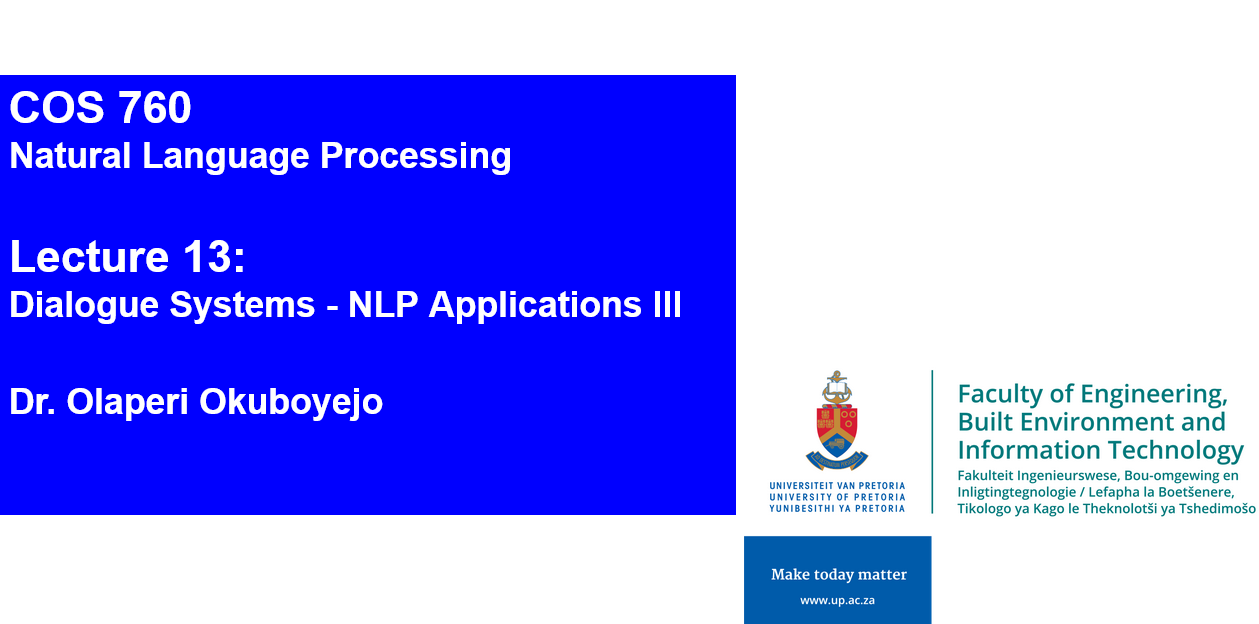

# COS 760 - NATURAL LANGAUGE PROCESSING
## Module 13: NLP Applications III - Dialogue Systems

## Introduction to Dialogue-based systems.

Dialogue systems (also known as conversational agents) are systems that enable coherent conversations between humans and machines. These systems can interact through text, speech, or even gestures and graphics.

Earlier systems were rule-based (e.g. ELIZA). Today however, conversational agents are AI-driven platforms that use natural language processing (NLP) techiques.

### Task-oriented dialogue systems vs Chat bots
We often distinguish between two kinds of architectures.

**Task-oriented dialogue systems** converse with users to accomplish fixed dialogue system tasks like controlling appliances or finding restaurants, relying on a data structure called the *frame*, which represents the knowledge a system needs to acquire from the user (like the time to set an alarm clock).

**Chatbots**, by contrast, are designed to mimic the longer and more unstructured conversations or ‘chats’ characteristic of
human-human interaction.

Some modern systems incorporate aspects of both.

*Source: Recommended text; Chapter 15 - Jan '25 edition.*

We take a practical approach in this class to build an actual Chatbot. For a good understanding of the theoretical concepts, see Recommended text; Chapter 15 - Jan '25 edition.

## Goal: Build a COS 760 Chatbot using RAG and an LLM.

## Building a RAG-Powered Chatbot

Traditional chatbots powered solely by Large Language Models (LLMs)—like GPT-4 or Llama 3—are limited by their "knowledge cutoff" date and their tendency to "hallucinate" (confidently stating facts that aren't true). While these models are excellent at understanding and generating language, they do not have access to your private files or the most recent news.

To solve this, we use a technique called Retrieval-Augmented Generation (RAG). (This was covered in Lecture 12, but let's have a brief recap.

### What is RAG?
RAG gives an LLM a "digital library" to consult before it answers a question. Instead of relying only on its internal memory, the system does the following:
 - Retrieves relevant documents from a custom dataset (like PDFs, websites, or databases).
 - Augments the user's prompt by adding the retrieved information as context.
 - Generates a grounded, accurate response based specifically on that data.

 In this class project, we will build a chatbot that combines the reasoning power of an LLM with the precision of RAG.

### Get GROQ API Key
1. If you already have a GROQ API Key, move on.
2. Otherwise, get a free Groq key at console.groq.com. No credit card needed.
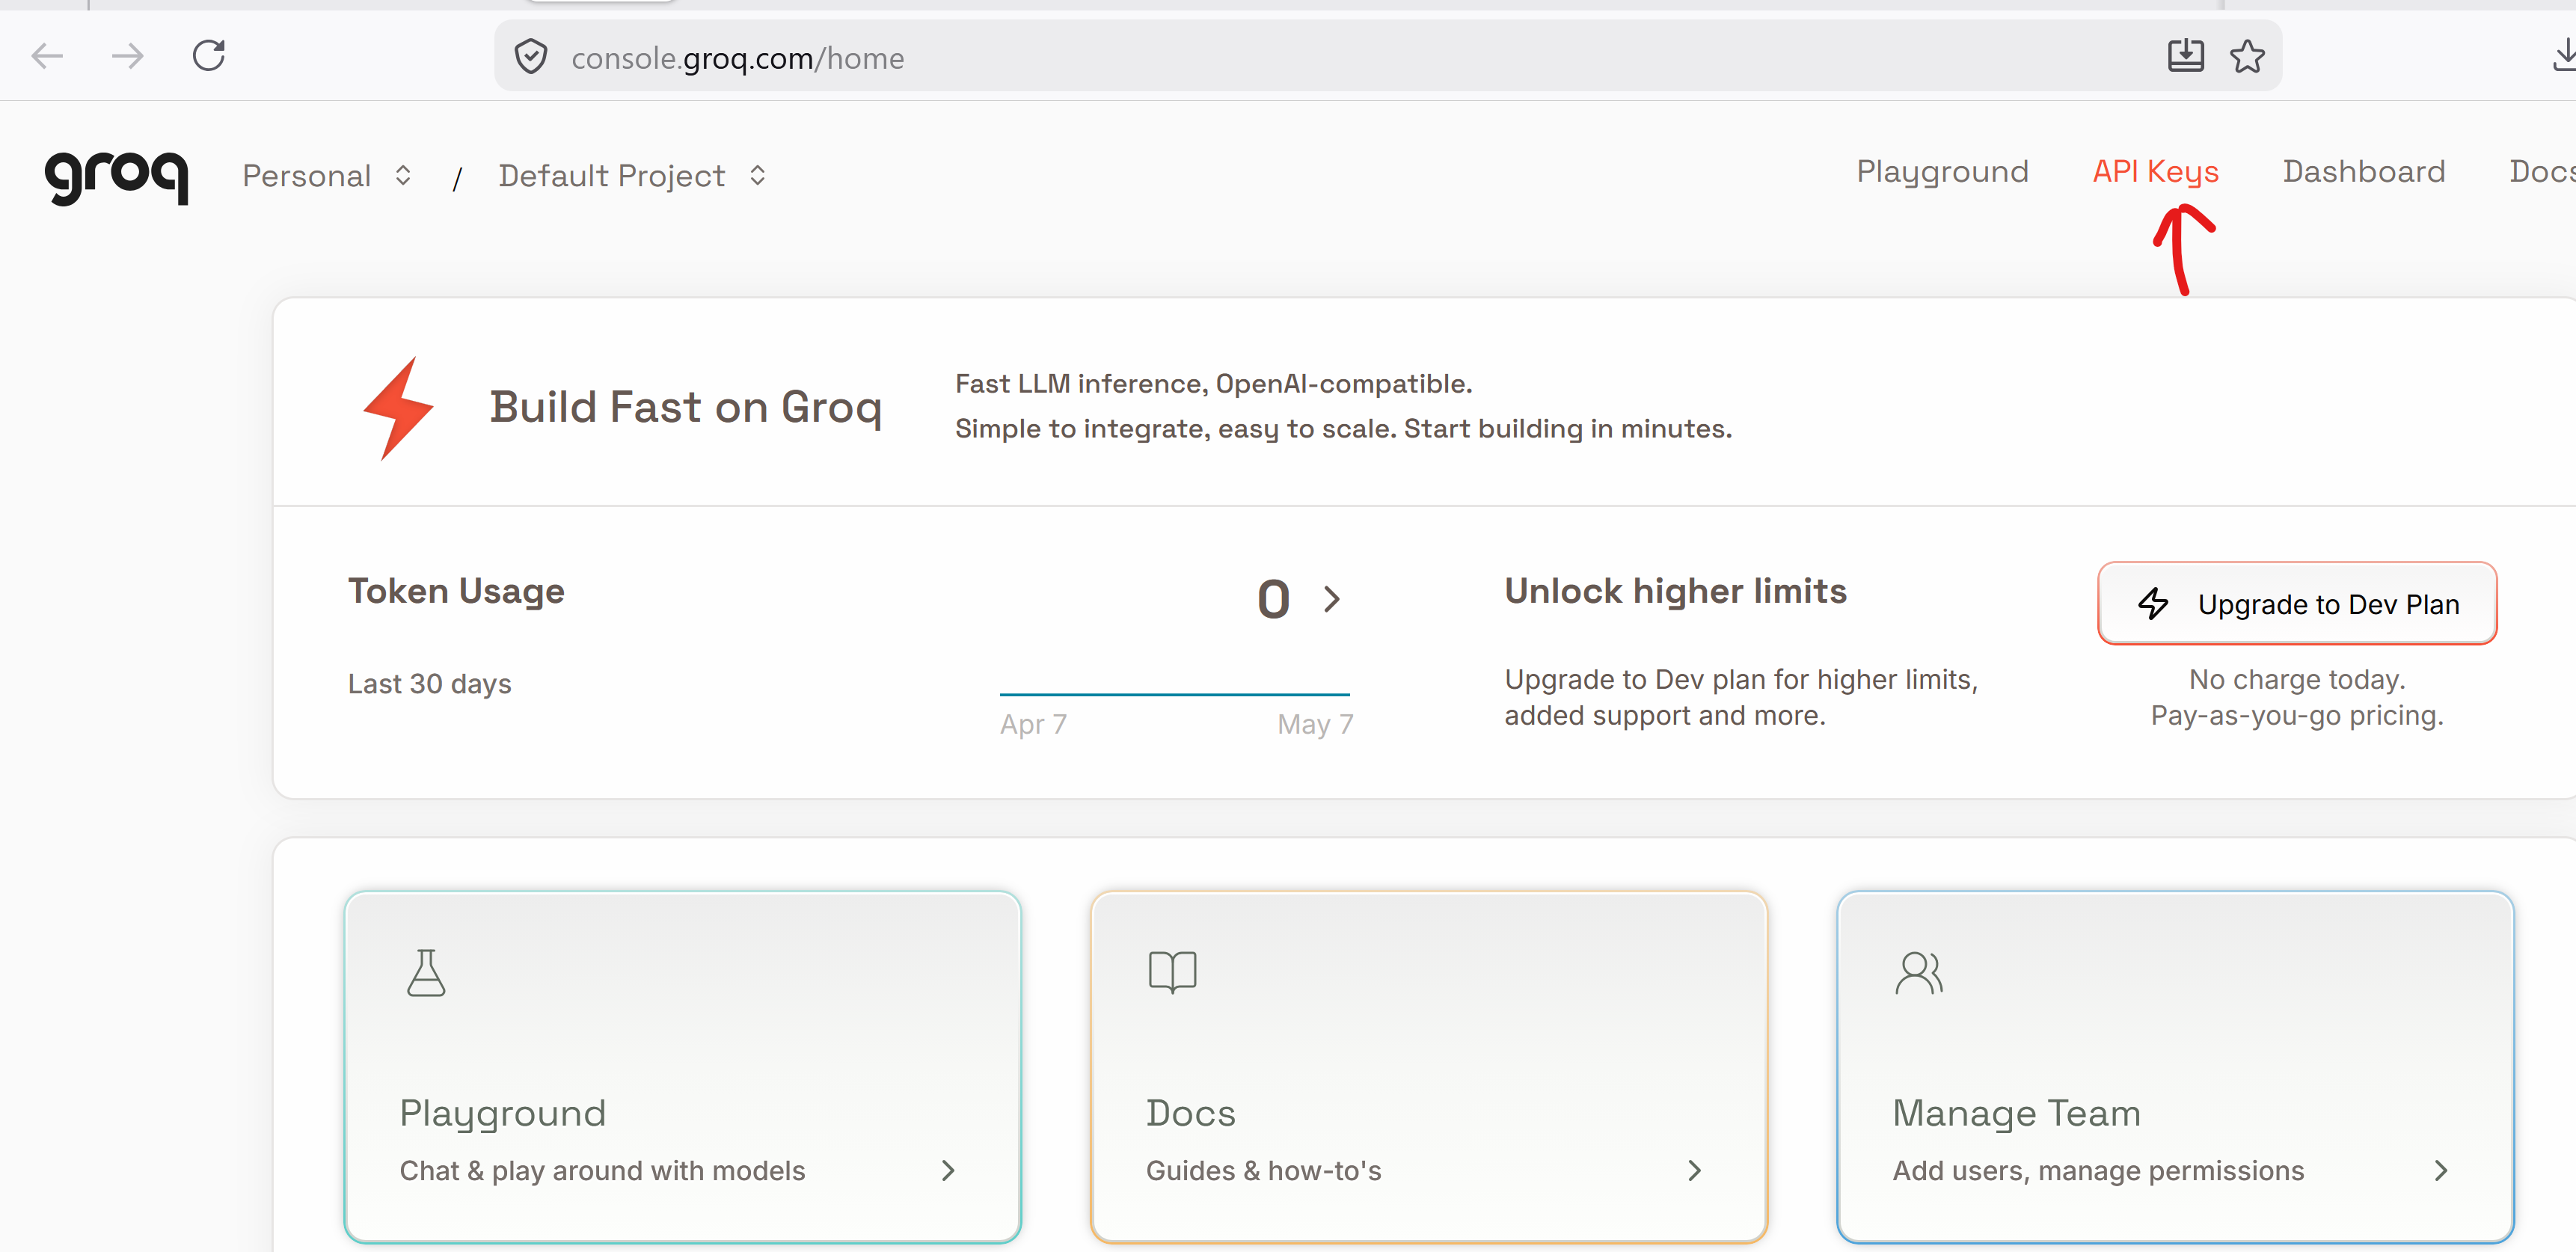######fff##djdsjjdjdfjdddddssssssssssdfjsdfvhjdsvds

### Set API Key

To securely set your GROQ API key using Colab Secrets, follow these steps:
1. Open Colab Secrets: On the left-hand side of your Colab notebook, look for the '🔑' icon (a key icon) in the toolbar. Click on it.
2. Add a New Secret: In the 'Secrets' panel that appears, click on the '+ Add new secret' button.
3. Configure the Secret:
        For Name, type GROQ_API_KEY (this is the environment variable name your code expects).
        For Value, paste your actual GROQ API key.
4. Save the Secret: Make sure the 'Notebook access' toggle is enabled for the current notebook, then click 'Done'.

## To run your app locally on streamlit at the end of the class

Do the following at the side (in the background),
1. Create a virtual environment and activate it
2. pip install streamlit openai sentence-transformers faiss-cpu PyPDF2


## Now let's setup our Notebook

1. Setup & Prerequisites

Install the required libraries. We will use
- *openai* for the LLM API,
- *sentence-transformers* for local embeddings,
- *faiss-cpu* as our vector store, and
- *PyPDF2* for loading our PDF documents.
- LLM - We'll be using *Llama 3* via *Groq* given that it is free.


In [5]:
# Install dependencies — run once
!pip install openai sentence-transformers faiss-cpu PyPDF2 tiktoken numpy

In [6]:
import os, re, json, textwrap
import numpy as np
from openai import OpenAI
from sentence_transformers import SentenceTransformer
import faiss
from PyPDF2 import PdfReader
from google.colab import userdata # Import userdata to access Colab Secrets
from openai import OpenAI  # Groq is OpenAI-compatible

# client = OpenAI(
#         api_key=os.getenv("GROQ_API_KEY"),
#     base_url="https://api.groq.com/openai/v1"
# )

# Attempt to get the API key from Colab Secrets
groq_api_key = userdata.get("GROQ_API_KEY")

# Check if the API key was successfully retrieved
if not groq_api_key:
    raise ValueError("GROQ_API_KEY not found in Colab Secrets. Please set it using the '🔑' icon.")

client = OpenAI(api_key=groq_api_key, base_url="https://api.groq.com/openai/v1")
print("✓ All imports successful")

✓ All imports successful


In [13]:
from google.colab import drive
drive.mount('/content/drive')
#We need this later on to load our pdf from our drive

Mounted at /content/drive



---



2. Set up our LLM and make a simple call.

In [7]:
# Demo: simple LLM call — observe how the model uses parametric knowledge
# Other LLMs you can try.
# model = "llama-3.3-70b-versatile"
# model = "llama-3.1-8b-instant"
# model = "llama-4-scout-17b-16e-instruct"  # newer Llama 4 family



def ask_llm(prompt, model="llama-3.3-70b-versatile", temperature=0.7):
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature
    )
    return response.choices[0].message.content

# Test: the LLM answers from memory (parametric knowledge)
answer = ask_llm("What is backwardness? Answer in 2 sentences.")
print(answer)

Backwardness refers to a state of being underdeveloped, unprogressive, or lagging behind in terms of social, economic, cultural, or technological advancements. It can manifest in various aspects, such as limited access to education, poor infrastructure, outdated practices, or a lack of exposure to modern ideas and innovations, ultimately hindering the growth and development of individuals, communities, or societies.


## Let's see the limitation of an LLM, ask it a specific question in a specific context that it does not have access to

In [8]:
# Test: the LLM answers from memory (parametric knowledge)
answer = ask_llm("When is the final project for COS 760 due")
print(answer)

I'm not aware of any information regarding a COS 760 course, including its schedule or assignment deadlines. If you're looking for specific details about a course, I recommend checking the course syllabus, contacting the instructor, or looking at the course website for the most up-to-date information. Is there anything else I can help you with?


3. The Problem: Knowledge Cutoffs & Hallucination

3.1 Knowledge cutoff

LLMs are trained on a static snapshot of the web. They have no awareness of events after their training cutoff date.

For our question on COS 760 (course materials), this means the model cannot answer questions about your specific lecture notes, assignments, or recent research.

3.2 Hallucination

When asked about something not in its training data, the model may generate plausible-sounding but incorrect information. This is a fundamental property of next-token prediction — the model is not "looking things up", it is generating the most likely continuation.

3.3 The "closed-book" problem

A vanilla LLM behaves like a student in a closed-book exam who has studied broadly but may not recall domain-specific details accurately. We want to give the model an open-book exam — with retrieved, verifiable source documents.

**Key insight:** the solution is not to fine-tune the model (expensive, static) but to retrieve and inject relevant context at inference time.

In [9]:
# Demonstrate hallucination on a course-specific question
hallucination_test = ask_llm(
    "What is the assignment deadline for Week 5 of COS 700 at our university?"
)
print("Without RAG:\n", hallucination_test)

Without RAG:
 I'm not aware of the specific details regarding the assignment deadline for Week 5 of COS 700 at your university. For the most accurate and up-to-date information, I recommend checking the course syllabus, the university's online portal, or contacting the instructor or department directly. They will be able to provide you with the correct deadline and any other relevant details.



4. RAG Architecture — Retrieval-Augmented Generation

4.1 What is RAG?

RAG combines a retriever with a generator. Given a query, the retriever finds the most relevant document chunks from a knowledge base; these are prepended to the prompt so the generator can produce a grounded answer.

4.2 The RAG pipeline

**Query** - User question encoded as a vector.

&darr;

**Retrieve** -
Top-k similar chunks from vector store

&darr;

**Augment** -
Inject chunks into prompt context

&darr;

**Generate**
LLM produces grounded answer

4.3 Offline vs. online phases

    Offline (indexing): load documents → split into chunks → embed each chunk → store in vector index.
    Online (inference): embed query → nearest-neighbour search → build augmented prompt → call LLM.

4.4 Chunking strategies

    Fixed-size — split every N tokens with overlap.
    Sentence / paragraph — respect natural text boundaries.
    Semantic chunking — split where embedding similarity drops (advanced).

For this demo we use fixed-size chunks of 300 tokens with 50-token overlap.


In [10]:
# ── Offline phase: Document loading and chunking ──────────────────────

def load_text_file(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

def load_pdf(path: str) -> str:
    reader = PdfReader(path)
    return " ".join(page.extract_text() or "" for page in reader.pages)

def chunk_text(text: str, chunk_size: int = 300, overlap: int = 50) -> list[str]:
    """Split text into overlapping word-based chunks."""
    words = text.split()
    chunks, start = [], 0
    while start < len(words):
        chunk = words[start : start + chunk_size]
        chunks.append(" ".join(chunk))
        start += chunk_size - overlap
    return chunks

# Example: use in-memory course notes (replace with real PDFs)
course_notes = """
Week 1: Introduction to Machine Learning. Topics: supervised learning,
loss functions, gradient descent. Assignment 1 due Friday Week 2.
Week 2: Neural Networks. Topics: perceptrons, activation functions,
multi-layer perceptrons. Assignment 2 due Friday Week 3.
Week 3: CNNs for image classification. Topics: convolutions, pooling,
ResNet. Assignment 3 (image classifier) due Friday Week 4.
Week 4: Sequence models. Topics: RNNs, LSTMs, vanishing gradients.
Week 5: Transformers and Attention. Reading: Vaswani et al. 2017.
Assignment 4 (text classifier) due Friday Week 6.
""" * 5  # repeat to simulate a longer document

chunks = chunk_text(course_notes, chunk_size=80, overlap=15)
print(f"Created {len(chunks)} chunks.")
print("First chunk:\n", chunks[0])
print("First chunk:\n", chunks[-1])

Created 7 chunks.
First chunk:
 Week 1: Introduction to Machine Learning. Topics: supervised learning, loss functions, gradient descent. Assignment 1 due Friday Week 2. Week 2: Neural Networks. Topics: perceptrons, activation functions, multi-layer perceptrons. Assignment 2 due Friday Week 3. Week 3: CNNs for image classification. Topics: convolutions, pooling, ResNet. Assignment 3 (image classifier) due Friday Week 4. Week 4: Sequence models. Topics: RNNs, LSTMs, vanishing gradients. Week 5: Transformers and Attention. Reading: Vaswani et al. 2017. Assignment 4 (text classifier) due Friday Week 6.
First chunk:
 al. 2017. Assignment 4 (text classifier) due Friday Week 6.


5. Embeddings & Vector Stores

5.1 What is an embedding?

An embedding maps a piece of text to a point in a high-dimensional vector space (e.g., 384 dimensions for all-MiniLM-L6-v2). Semantically similar texts land close together — measured by cosine similarity.

5.2 Embedding models

    all-MiniLM-L6-v2 — fast, local, 384-dim, free.
    text-embedding-3-small — OpenAI API, 1536-dim, paid.
    nomic-embed-text — strong open-source alternative.

5.3 Vector stores

A vector store (or vector database) stores embeddings and supports fast approximate nearest-neighbour (ANN) search. Options: FAISS (local, in-memory), Chroma (local persistent), Pinecone / Weaviate (cloud-scale).

We use FAISS with a flat L2 index — exact search, suitable for up to ~100k chunks.

N.B: An index in FAISS is just a container that stores vectors and knows how to search them quickly. Think of it like a filing cabinet — you put vectors in, and later you ask it "which vectors are closest to this one?" and it gives you the answer fast.

In [15]:
# ── Embed chunks and build FAISS index ────────────────────────────────

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

def build_index(chunks: list[str]):
    print("Embedding chunks...")
    embeddings = embed_model.encode(chunks, show_progress_bar=True,
                                       convert_to_numpy=True)
    # SentenceTransformer gives you float64 by default. FAISS wants float32.
    embeddings = embeddings.astype("float32")
    dim = embeddings.shape[1] #get the dimensionality of the embedding
    #  IndexFlatL2 means it will perform an exhaustive search using Euclidean (L2) distance to find the nearest neighbors.
    index = faiss.IndexFlatL2(dim) # A FAISS index is created, an empty index
    index.add(embeddings) #add the embeddings to the FAISS index, so we can search them
    print(f"Index built: {index.ntotal} vectors, {dim}-dim")
    return index, embeddings

index, embeddings = build_index(chunks)

def retrieve(query: str, k: int = 3) -> list[str]:
    """Return the k most relevant chunks for a query."""
    # user's query is also converted into an embedding using the same embed_model ...and cast to float32.
    qvec = embed_model.encode([query], convert_to_numpy=True).astype("float32")
    distances, indices = index.search(qvec, k) # The FAISS index.search method is used here. It takes the query embedding (qvec) and the number of desired results (k) to find the k most similar embeddings in the index.
    # return [chunks[i] for i in indices[0] if i < len(chunks)], distances
    return [chunks[i] for i in indices[0] if i < len(chunks)]

# Quick test
# results, d = retrieve("When is Assignment 4 due?")
results = retrieve("When is Assignment 4 due?")
# print(d) #just trying to viualize the distance
for i, r in enumerate(results):
    print(f"\nChunk {i+1}:\n{r}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Index built: 7 vectors, 384-dim

Chunk 1:
al. 2017. Assignment 4 (text classifier) due Friday Week 6.

Chunk 2:
Friday Week 4. Week 4: Sequence models. Topics: RNNs, LSTMs, vanishing gradients. Week 5: Transformers and Attention. Reading: Vaswani et al. 2017. Assignment 4 (text classifier) due Friday Week 6. Week 1: Introduction to Machine Learning. Topics: supervised learning, loss functions, gradient descent. Assignment 1 due Friday Week 2. Week 2: Neural Networks. Topics: perceptrons, activation functions, multi-layer perceptrons. Assignment 2 due Friday Week 3. Week 3: CNNs for image classification. Topics: convolutions, pooling, ResNet. Assignment 3 (image classifier) due

Chunk 3:
Learning. Topics: supervised learning, loss functions, gradient descent. Assignment 1 due Friday Week 2. Week 2: Neural Networks. Topics: perceptrons, activation functions, multi-layer perceptrons. Assignment 2 due Friday Week 3. Week 3: CNNs for image classification. Topics: convolutions, pooling, ResN

In [16]:
type(index)


faiss.swigfaiss_avx2.IndexFlatL2

6. Building the RAG Chatbot

6.1 System prompt design

The system prompt instructs the LLM to answer only from the provided context. This is the key safety mechanism — it prevents the model from hallucinating facts not in our course materials.

6.2 The augmented prompt pattern

The full prompt sent to the LLM at inference time:

> System: You are a helpful course assistant. Answer using ONLY the context below. If the answer is not in the context, say "I don't know."




> Context: [retrieved chunk 1] ... [retrieved chunk k]

> User: [student question]

In [17]:
# ── The RAG chatbot function ───────────────────────────────────────────

SYSTEM_PROMPT = """You are a helpful assistant for this university course module.
Answer questions using ONLY the provided context passages.
If the answer cannot be found in the context, respond with:
"I don't have that information in the course materials."
Always cite which part of the context your answer comes from."""

def rag_chat(question: str, k: int = 3, verbose: bool = True) -> dict:
    # Step 1: Retrieve relevant chunks
    context_chunks = retrieve(question, k=k)
    context_str = "\n\n---\n\n".join(
        f"[Source {i+1}]: {c}" for i, c in enumerate(context_chunks)
    )

    # Step 2: Build augmented prompt
    user_message = f"""Context:\n{context_str}\n\nQuestion: {question}"""

    # Step 3: Generate answer
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_message}
        ],
        temperature=0.2  # low temp for factual Q&A
    )
    answer = response.choices[0].message.content

    if verbose:
        print(f"Question: {question}\n")
        print(f"Retrieved {len(context_chunks)} chunks.")
        # print(f"Context used: \n{context_str}\n")

        print(f"\nAnswer: {answer}")

    return {"answer": answer, "sources": context_chunks}

# Test the chatbot
result = rag_chat("When is Assignment 4 due?")
# print(result)

Question: When is Assignment 4 due?

Retrieved 3 chunks.

Answer: Assignment 4 (text classifier) is due Friday Week 6, as stated in [Source 1], [Source 2], and [Source 3].


Your turn
Ask the Chatbot a Question not in the sources given. Like when is a given test or examination.

In [18]:
result = rag_chat("When is Test 4 ?")


Question: When is Test 4 ?

Retrieved 3 chunks.

Answer: I don't have that information in the course materials. 

The context only mentions assignments (Assignment 1, Assignment 2, Assignment 3, Assignment 4) and their due dates, but it does not mention any tests, including Test 4. (Source 1, Source 2, Source 3)


In [19]:
result = rag_chat("When is the exam ?")


Question: When is the exam ?

Retrieved 3 chunks.

Answer: I don't have that information in the course materials.


Next, Let's load our Course Outline

In [14]:
import os

# List files in the current directory to help locate the uploaded file.
print(os.listdir('/content'))

# If your file is in a specific subdirectory, you might need to adjust the path.
# For example, if you uploaded to your Google Drive and mounted it:
print(os.listdir('/content/drive/MyDrive/Colab Notebooks'))

['.config', 'drive', 'sample_data']
['Lecture 13: Building a Chatbot.ipynb', 'Untitled0.ipynb', 'Untitled1.ipynb', 'ngram_models_honours_nlp.ipynb', 'ngram_models_product_reviews.ipynb', 'hw1_1.ipynb', 'ngram_models_product_reviews_SOLUTIONS.ipynb', 'hw1.3.ipynb', 'logistic_regression_sentiment_class_exercise.ipynb', 'logistic_regression_sentiment_SOLUTIONS.ipynb', 'COS760_Lecture3_NGram_Lecture_Slides_Notebook.ipynb', 'hw1_3_old.ipynb', 'hw1_3.ipynb', 'llm_fundamentals_lecture.ipynb', 'Untitled2.ipynb', 'Large Language Modelling - Practical.ipynb', 'Untitled3.ipynb', 'COS760_Lecture9_Lecture_Practical.ipynb', 'Copy of hw2-1-simple-classifier.ipynb', 'Copy_of_self_peer_evaluation_808_2025.ipynb', 'Untitled', 'mt_chapter12_practical.ipynb', 'COS760_Lecture11_MachineTranslation_practical.ipynb', 'COS760_StudyGuide_2026_V2.pdf']


In [20]:
from google.colab import drive
drive.mount('/content/drive')

course_outline_pdf = load_pdf('/content/drive/MyDrive/Colab Notebooks/COS760_StudyGuide_2026_V2.pdf')

chunks_pdf = chunk_text(course_outline_pdf, chunk_size=80, overlap=15)
print(f"Created {len(chunks_pdf)} chunks.")
print("First chunk:\n", chunks_pdf[0])
print("First chunk:\n", chunks_pdf[-1])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Created 44 chunks.
First chunk:
 School of Information Technology Department of Computer Science Natural language processing (COS 760) Lecturers: Dr Abiodun Modupe; BDS Coordinator, CS. UP . Dr Olaperi Okuboyejo; Senior Lecturer, CS. UP Last Revision: February 5, 2026 ©Copyright reserved i Contents 1 Introduction 1 1.1 Welcome . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
First chunk:
 booking calender or send an email. 8


In [21]:
index_pdf, embeddings_pdf = build_index(chunks_pdf)


Embedding chunks...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Index built: 44 vectors, 384-dim


In [22]:
results_pdf = retrieve("When is Assignment 4 due?")
print(results)

['al. 2017. Assignment 4 (text classifier) due Friday Week 6.', 'Friday Week 4. Week 4: Sequence models. Topics: RNNs, LSTMs, vanishing gradients. Week 5: Transformers and Attention. Reading: Vaswani et al. 2017. Assignment 4 (text classifier) due Friday Week 6. Week 1: Introduction to Machine Learning. Topics: supervised learning, loss functions, gradient descent. Assignment 1 due Friday Week 2. Week 2: Neural Networks. Topics: perceptrons, activation functions, multi-layer perceptrons. Assignment 2 due Friday Week 3. Week 3: CNNs for image classification. Topics: convolutions, pooling, ResNet. Assignment 3 (image classifier) due', 'Learning. Topics: supervised learning, loss functions, gradient descent. Assignment 1 due Friday Week 2. Week 2: Neural Networks. Topics: perceptrons, activation functions, multi-layer perceptrons. Assignment 2 due Friday Week 3. Week 3: CNNs for image classification. Topics: convolutions, pooling, ResNet. Assignment 3 (image classifier) due Friday Week 4.

In [23]:
result_pdf = rag_chat("When is Test 4 ?")


Question: When is Test 4 ?

Retrieved 3 chunks.

Answer: I don't have that information in the course materials. 

The context only mentions assignments (Assignment 1, Assignment 2, Assignment 3, Assignment 4) and their due dates, but it does not mention any tests, including Test 4. (Source 1, Source 2, Source 3)


In [24]:
result_3 = rag_chat("What is the assessment criteria?")


Question: What is the assessment criteria?

Retrieved 3 chunks.

Answer: I don't have that information in the course materials.


In [25]:
result_3 = rag_chat("Give me full details of the entire assessment crtieria?")


Question: Give me full details of the entire assessment crtieria?

Retrieved 3 chunks.

Answer: I don't have that information in the course materials. 

The provided context only mentions the due dates and topics for Assignments 1, 2, 3, and 4, but does not provide full details of the entire assessment criteria (Source 1, Source 2, Source 3).


In [26]:
result_3 = rag_chat("Breakdown the assignment criteria?")


Question: Breakdown the assignment criteria?

Retrieved 3 chunks.

Answer: I don't have that information in the course materials.


In [27]:
result_3 = rag_chat("What is the total")


Question: What is the total

Retrieved 3 chunks.

Answer: I don't have that information in the course materials.


In [28]:
# ── Multi-turn chat with conversation history ─────────────────────────

class CourseAssistant:
    def __init__(self, k=3):
        self.k = k
        self.history = []  # list of {role, content} dicts

    def chat(self, question: str) -> str:
        context_chunks = retrieve(question, k=self.k)
        context_str = "\n---\n".join(
            f"[{i+1}] {c}" for i, c in enumerate(context_chunks)
        )
        # Prepend fresh context to the latest user message
        augmented = f"Context:\n{context_str}\n\nQuestion: {question}"
        self.history.append({"role": "user", "content": augmented})

        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "system", "content": SYSTEM_PROMPT}]
                     + self.history,
            temperature=0.2
        )
        reply = response.choices[0].message.content
        self.history.append({"role": "assistant", "content": reply})
        return reply, context_chunks



Now it can answer our previous final question-  'What is the total?'. Without the history, it did not know what it refered to.

In [29]:
bot = CourseAssistant()
a1, s1 = bot.chat("Give me full details of the entire assessment crtieria?")
a2, s2 = bot.chat("Breakdown the assignment criteria")
a3, s3 = bot.chat("What is the total")

print("\nWeek 5:", a3)


Week 5: I don't have that information in the course materials.

The context does not provide information about the total number of assignments, total marks, or any other total value. It only mentions the individual assignments and their due dates:

- Assignment 1 (due Friday Week 2)
- Assignment 2 (due Friday Week 3)
- Assignment 3 (image classifier, due Friday Week 4)
- Assignment 4 (text classifier, due Friday Week 6)

However, it can be inferred that there are at least 4 assignments, as mentioned in the context ([1], [2], and [3]).


Another example (History works when you are using a pronoun to refere back to a previous question)

Try out these examples with and without history.

    "When is Assignment 1 due?",

    "And Assignment 2?",          # no history = no idea what was just asked

    "Which of those is harder?"   # impossible without history


In [30]:
# Let's see the history

# After running any of the WITH HISTORY examples, print the full history
import json

print("\nFull conversation history stored in bot:")
print("-" * 40)
for i, msg in enumerate(bot.history):
    role = msg["role"].upper()
    # trim long context injections for display
    content = msg["content"][:120] + "..." if len(msg["content"]) > 120 else msg["content"]
    print(f"\n[{i}] {role}:\n{content}")


Full conversation history stored in bot:
----------------------------------------

[0] USER:
Context:
[1] al. 2017. Assignment 4 (text classifier) due Friday Week 6.
---
[2] Learning. Topics: supervised learning, ...

[1] ASSISTANT:
I don't have that information in the course materials. 

The context only provides information about the assignments and...

[2] USER:
Context:
[1] al. 2017. Assignment 4 (text classifier) due Friday Week 6.
---
[2] Learning. Topics: supervised learning, ...

[3] ASSISTANT:
I don't have that information in the course materials.

The context only provides information about the assignments and ...

[4] USER:
Context:
[1] al. 2017. Assignment 4 (text classifier) due Friday Week 6.
---
[2] Friday Week 4. Week 4: Sequence models....

[5] ASSISTANT:
I don't have that information in the course materials.

The context does not provide information about the total number ...


7. Evaluation & Best Practices

7.1 RAG evaluation dimensions

    - Retrieval precision — are the retrieved chunks actually relevant?
    - Answer faithfulness — does the answer only use information from the context?
    - Answer relevance — does the answer address the question?

Example Frameworks: RAGAs, TruLens, or simple LLM-as-judge evaluation.


7.2 Common failure modes

    - Chunk too large → noisy context, high token cost.
    - Chunk too small → incomplete context, missing surrounding meaning.
    - Wrong embedding model for domain-specific text (use domain-tuned embedders).
    - No overlap between chunks → answers split across chunk boundary.

7.3 Production checklist

    - Use a persistent vector store (Chroma / Pinecone) — not in-memory FAISS.
    - Re-index when course materials are updated (Like we did when we added the course outline).
    - Add metadata filters (week, topic) for hybrid search.
    - Log queries and answers for continuous improvement.
    - Add a guardrail to detect off-topic questions.


In [31]:
# ── Simple LLM-as-judge faithfulness check ─────────────────────────────

def evaluate_faithfulness(question: str, answer: str, context: list[str]) -> dict:
    context_str = "\n".join(context)
    prompt = f"""
Question: {question}
Context: {context_str}
Answer: {answer}

Is the answer fully supported by the context above?
Respond with JSON only: {{"faithful": true/false, "reason": "..."}}
"""
    raw = ask_llm(prompt, temperature=0)
    try:
        return json.loads(raw)
    except:
        return {"faithful": None, "raw": raw}

q = "When is Assignment 4 due?"
res = rag_chat(q, verbose=False)
eval_result = evaluate_faithfulness(q, res["answer"], res["sources"])
print(json.dumps(eval_result, indent=2))

{
  "faithful": true,
  "reason": "The context explicitly states 'Assignment 4 (text classifier) due Friday Week 6' multiple times, which directly supports the answer."
}


8. Class Exercises

    - Load your own document (actually multiple documents)
    - Tune chunk size — try chunk_size of 100, 300, and 600 words. Compare retrieved passages qualitatively.
    - Swap the embedding model — replace all-MiniLM-L6-v2 with BAAI/bge-small-en-v1.5. Does retrieval improve? Try several other models
    - Add metadata filtering — tag each chunk with its week number and filter by it before the vector search.
    - Evaluate — write 10 Q&A pairs by hand, run the chatbot, and score faithfulness automatically.

9. Further reading

    - Lewis et al. (2020) — "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks" (the original RAG paper).
    - Gao et al. (2023) — "Retrieval-Augmented Generation for Large Language Models: A Survey".
    - LangChain / LlamaIndex documentation — production RAG patterns.
    - RAGAs library — automated RAG evaluation metrics.


## Next, try to run this locally on StreamLit
- Follow the steps given at the beginning of the notebook to set up for Streamlit
- Download the app.py file from ClickUP
- On your terminal,
  - ensure the venv you setup is activated,
  - navigate to the folder having your app.py file
  - run 'streamlit run app.py'. This might vary slightly depending on your OS and where you are running from.
  
## After class, launch your mini chatbox on the Streamlit cloud community (via your Github) and share with your friends.